### Calculate Top-k Accuracy (TTA20)

In [1]:
from rdkit import Chem
from neutral import NeutraliseCharges
from multiprocessing import Pool
from rdkit import RDLogger
import pandas as pd
from rdkit.Chem.MolStandardize import rdMolStandardize
RDLogger.DisableLog('rdApp.*')

def canonicalize_smiles(smiles):
    if len(smiles)==0:
        return ''
    mol = Chem.MolFromSmiles(smiles)
    # lfc = MolStandardize.fragment.LargestFragmentChooser()
    
    if mol is not None:
        # mol2 = lfc.choose(mol)
        smi2=Chem.MolToSmiles(mol, isomericSmiles=True)
        smi,_=NeutraliseCharges(smi2)
        return smi 
    else:
        return ''
# df['substrate']=df['substrate'].apply(canonicalize_smiles)

In [2]:
#把带多个的拆成单个

In [3]:
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import MolStandardize
def canonicalize_predict(smiles):
    if len(smiles)==0:
        return ''
    mol = Chem.MolFromSmiles(smiles)
    lfc = MolStandardize.fragment.LargestFragmentChooser()
    
    if mol is not None:
        mol2 = lfc.choose(mol)
        smi2=Chem.MolToSmiles(mol2, isomericSmiles=True)
        smi,_=NeutraliseCharges(smi2)
        return smi
    else:
        return ''

In [4]:
# sub=list(map(remove_leavegroup,true_reactseq_lis))

## label

In [5]:
import os
import pandas as pd
from e_smiles import get_e_smiles, merge_smiles, get_edit_from_e_smiles
from joblib import Parallel, delayed
from rdkit import Chem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import AllChem

def process_smiles(smiles):
    return merge_smiles(smiles)




rdkit version:2022.03.2


In [6]:
def kekulize_smiles(smi):
    smi = smi.replace(' ','')
    mol = Chem.MolFromSmiles(smi)
    Chem.Kekulize(mol, clearAromaticFlags = True)
    smi = Chem.MolToSmiles(mol, canonical = False, kekuleSmiles = True)
    return smi

In [7]:
n_best = 20
substrate_lis = []
true_tgt_lis = []
with open('test_128_input.txt') as f:
    for line in f.readlines():
        line = line.replace('\n','').replace(" ","").split("|")[0]
        substrate_lis += [line] * n_best
        true_tgt_lis.append(line)

In [8]:

pred_tgt_lis = []
with open('128_argue10_nbest20.txt') as f:
    for line in f.readlines():
        line = line.replace('\n','').replace(" ","")
        pred_tgt_lis.append(line)

In [9]:
len(pred_tgt_lis)

25600

In [10]:
pred = [f"{x}>>>{y}" for x, y in zip(substrate_lis, pred_tgt_lis)]

In [11]:
pred_smi= Parallel(n_jobs=-1)(delayed(process_smiles)(x) for x in pred)

rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:2022.03.2
rdkit version:20

In [12]:
def remove_leavegroup(smi):
    frag = smi.split(".")
    result = [i for i in frag if 'Au' not in i]
    return ".".join(result)

predict_smiles_all=list(map(remove_leavegroup,pred_smi))


In [13]:
pd.DataFrame(predict_smiles_all).to_csv("all_smi_128.csv")

In [14]:
strings_with_dot = [smiles for smiles in predict_smiles_all if '.' in smiles]

In [15]:
len(strings_with_dot)

2181

In [16]:
predict_smiles_dict = {}
predict_smiles_all_record = [smiles for smiles in predict_smiles_all if '.' in smiles]
for smiles in predict_smiles_all_record:
    
    canonical_smiles = canonicalize_predict(smiles)
    if canonical_smiles:
        predict_smiles_dict[canonical_smiles] = smiles

In [17]:
from collections import defaultdict, Counter
predict_smiles_all_record = [smiles for smiles in predict_smiles_all if '.' in smiles]

# 使用 defaultdict 记录每个 canonical_smiles 对应的所有原始 smiles 的频率
smiles_frequency = defaultdict(Counter)

for smiles in predict_smiles_all_record:
    canonical_smiles = canonicalize_predict(smiles)
    if canonical_smiles:
        smiles_frequency[canonical_smiles][smiles] += 1

# 构建结果字典，只保留出现频率最高的原始 smiles
predict_smiles_dict = {canonical_smiles: max(counter, key=counter.get)
                       for canonical_smiles, counter in smiles_frequency.items()}

In [18]:
len(predict_smiles_all)

25600

In [19]:
len(predict_smiles_dict)

530

In [20]:
predict_smiles=list(map(canonicalize_predict,predict_smiles_all))

In [21]:
len(predict_smiles)

25600

In [22]:
predict_cocan_smiles=list(map(canonicalize_smiles,predict_smiles))

In [23]:
len(predict_cocan_smiles)

25600

In [24]:
# test=pd.read_csv("/home/wangyitian/opennmt-model/other_method_result/origin_65_true.csv")

In [25]:
test =pd.read_csv("smiles_128_input.csv")


In [26]:
truth=test['metabolite']

In [27]:
len(truth)

128

### Prediction

### Calculate top-k accuracy

In [28]:
fold = 10
num = 128
n = n_best #nbest

score_1 = []
for i in range(fold):
    for j in range(num):
        for k in range(1,n+1):
            score_1.append(1/k**2)       # square  

In [29]:
len(predict_cocan_smiles)

25600

In [30]:
vote_score_lis = [-1]*len(predict_cocan_smiles) 

id=[]

for j in range(num):
    smiles_score_dic = {}
    for i in range(fold):
        for k in range(n):
            idx = j * fold * n + i*n + k
            id.append(idx)
            smiles = predict_cocan_smiles[idx]
            smiles = smiles
            s = score_1[idx]
            if smiles == '':
                s = 0
            
            if smiles not in smiles_score_dic:
                smiles_score_dic[smiles] = s
            else:
                smiles_score_dic[smiles] += s

    for i in range(fold):
        for k in range(n):
            idx = j * fold * n + i*n + k
            smiles = predict_cocan_smiles[idx]
            vote_score = smiles_score_dic[smiles]
            vote_score_lis[j * fold * n + i*n + k] = vote_score

In [31]:
max(id)

25599

In [32]:
pre_smiles_50_lis = []
pre_reactseq_50_lis = []

for j in range(num):
    smiles_g = []
    vote_score_g = []
    for i in range(fold):
        for k in range(n):
            idx = j * fold * n + i*n + k
            smiles_g.append(predict_cocan_smiles[idx])
            vote_score_g.append(vote_score_lis[idx])
            # reactseq_g.append(reactseq_lis[idx])
    #print(smiles_g)
    #print(vote_score_g)
    #print(reactseq_g)
    
    zip_a_b_c = zip(smiles_g,  vote_score_g)
    sorted_zip = sorted(zip_a_b_c, key=lambda x:x[-1],reverse= True)
    smiles_g,  vote_score_g = zip(*sorted_zip)
    
    pre_smiles_50 = []
    # pre_reactseq_50 = []
    for i in smiles_g:
        if i not in pre_smiles_50 and len(pre_smiles_50) < 50:
            pre_smiles_50.append(i)
            # pre_reactseq_50.append(j)

    if len(pre_smiles_50) < 50:
        pre_smiles_50 = pre_smiles_50 + [''] * (50-len(pre_smiles_50))
        # pre_reactseq_50 = pre_reactseq_50 + [pre_reactseq_50[-1].split('>>>')[0]+'>>>'] * (50-len(pre_reactseq_50))
        
    pre_smiles_50_lis.append(pre_smiles_50)
    # pre_reactseq_50_lis.append(pre_reactseq_50)

In [33]:
len(pre_smiles_50_lis[0])

50

In [34]:
len(pre_smiles_50_lis)

128

In [35]:
def get_similarity(smiles1, smiles2):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 and mol2:
        fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, 2, nBits=2048)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, 2, nBits=2048)
        return TanimotoSimilarity(fp1, fp2)
    return 0

In [36]:
num=128
all=[]
for i in range(num):
    data=[]
    for k in range(20):     
        data.append(pre_smiles_50_lis[i][k])
    all.append("|".join(data))

In [37]:
data =pd.read_csv("smiles_128_input.csv")


In [38]:
data['predict']=all

In [39]:
data

,id,substrate,metabolite,predict
0,0,CC(/C=C/C12OC1(C)CCCC2(C)C)=C\C=C\C(C)=C\C(=O)O,CC(/C=C/[C@]12O[C@]1(C)CCCC2(C)C)=C\C=C\C(C)=C...,CC(/C=C/C1(O)C(C)(C)CCCC1(C)O)=C\C=C\C(C)=C\C(...
1,1,CC(=O)NC1=CC=C2C(=C1)C(C1=CC=CC=C1Cl)=NCC(=O)N2,CC(=O)Nc1ccc2c(c1)C(c1ccccc1Cl)=NC(O)C(=O)N2,Nc1ccc2c(c1)C(c1ccccc1Cl)=NCC(=O)N2|CC(=O)Nc1c...
2,2,CC(=O)NC1=CC=CC(N2C(=O)N(C3CC3)C(=O)C3=C(NC4=C...,Cc1c(=O)n(C)c(Nc2ccc(I)cc2F)c2c(=O)n(C3CC3)c(=...,Cc1c(=O)n(C)c(Nc2ccc(I)cc2F)c2c(=O)n(C3CC3)c(=...
3,3,CC(C)(C)C1=CC(C(C)(C)C)=C(NC(=O)C2=CNC3=CC=CC=...,CC(C)(C)c1cc(C(C)(C)C(=O)O)c(O)cc1NC(=O)c1c[nH...,CC(C)(C)c1cc(C(C)(C)CO)c(O)cc1NC(=O)c1c[nH]c2c...
4,4,CC(C)(C)C1=CC(NC(=O)NC2=CC=C(C3=CN4C(=N3)SC3=C...,CC(C)(CO)c1cc(NC(=O)Nc2ccc(-c3cn4c(n3)sc3cc(OC...,CC(C)(CO)c1cc(NC(=O)Nc2ccc(-c3cn4c(n3)sc3cc(OC...
...,...,...,...,...
123,123,OC(C1=CC=CC=C1)(C1=CC=CC=C1)C12CC[N+](CCOCC3=C...,OCC[N+]12CCC(C(O)(c3ccccc3)c3ccccc3)(CC1)CC2|O...,OCC[N+]12CCC(C(O)(c3ccccc3)c3ccccc3)(CC1)CC2|O...
124,124,OC[C@H]1O[C@@H](C2=CC=C(Cl)C(CC3=CC=C(OCCOC4CC...,O=C(O)[C@H]1OC(O[C@@H]2[C@@H](O)[C@H](c3ccc(Cl...,OC[C@H]1O[C@@H](c2ccc(Cl)c(Cc3ccc(OCCOC4CC4O)c...
125,125,OCC1=NC=C2N1C1=CC=C(Cl)C=C1C(C1=CC=CC=C1F)=NC2,OCc1ncc2n1-c1ccc(Cl)cc1C(c1ccccc1F)=NC2O|O=C(O...,O=Cc1ncc2n1-c1ccc(Cl)cc1C(c1ccccc1F)=NC2|OCc1n...
126,126,OC1=CC=C(COCC[N+]23CCC(C(O)(C4=CC=CC=C4)C4=CC=...,O=C(O)C1OC(Oc2ccc(COCC[N+]34CCC(C(O)(c5ccccc5)...,Oc1ccc(COCC[N+]23CCC(C(O)(c4ccccc4)c4ccc(O)cc4...


In [40]:
df=data.copy()

In [53]:
import pandas as pd
from rdkit import Chem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import AllChem

# 定义相似度函数
def get_similarity(smiles1, smiles2):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 and mol2:
        fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, 2, nBits=2048)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, 2, nBits=2048)
        return TanimotoSimilarity(fp1, fp2)
    return 0

# 假设 df 是你的数据框
top = [5, 10, 13, 20]
for top_i in top:
    corr = 0 
    at_least_one, at_least_half, all_metabolites = 0, 0, 0
    len_preds, len_corr_preds, len_actual_metabolites, invalid = 0, 0, 0, 0
    no_correct_predictions_indices = []  # 记录没有正确预测的行的索引

    # 遍历每一行
    for i in range(len(df)):
        substrate = df.iloc[i]['substrate']
        true_metabolites = df.iloc[i]['metabolite'].strip().split('|')
        original_preds = df.iloc[i]['predict'].strip().split('|')[:top_i]
        expanded_preds = []
        for pred in original_preds:
            expanded_preds.extend(pred.split('.'))
        original_preds = expanded_preds
        
        unique_preds = list(set(original_preds))

        original_preds = unique_preds  # 去重后的预测值
        len_preds += len(original_preds)

        corr_preds = []
        preds_to_remove = []
        
        for true_metabolite in true_metabolites:
            for pred in original_preds:
                try:
                    pred = Chem.MolToSmiles(Chem.MolFromSmiles(pred))
                except:
                    print(pred)
                    invalid += 1
                    continue
                if get_similarity(pred, true_metabolite) == 1:
                    corr_preds.append(pred)
                    preds_to_remove.append(pred)
                    break  # 跳出内层循环，防止同一预测值多次计入

        # 移除已匹配的预测值，确保每个预测值只匹配一次
        original_preds = [pred for pred in original_preds if pred not in preds_to_remove]
        
        if len(corr_preds) > 0:
            at_least_one += 1
        else:
            no_correct_predictions_indices.append(i)  # 记录没有正确预测的行的索引
        if len(corr_preds) >= len(true_metabolites) / 2:
            at_least_half += 1
        if len(corr_preds) == len(true_metabolites):
            all_metabolites += 1

        len_corr_preds += len(corr_preds)
        len_actual_metabolites += len(true_metabolites)

    with open("results_128.log", 'a') as f:
        f.write(
            ",".join([
                str("top"+str(top_i)), 
                "{:.2%}".format(at_least_one / len(df)),  # at_least_one_metabolite
                "{:.2%}".format(at_least_half / len(df)),  # at_least_half_metabolites
                "{:.2%}".format(all_metabolites / len(df)),  # all_metabolites
                "{:.2%}".format(len_corr_preds / len_preds),  # precision
                "{:.2%}".format(len_corr_preds / len_actual_metabolites),  # recall
            ]) + "\n"
        )

    # 输出没有正确预测的行的索引
    print(f"Top {top_i}: 没有任何正确预测的行的索引: {no_correct_predictions_indices}")


Top 5: 没有任何正确预测的行的索引: [3, 5, 9, 10, 24, 28, 33, 39, 45, 47, 49, 50, 51, 54, 55, 57, 60, 61, 63, 64, 67, 69, 70, 71, 72, 76, 78, 79, 80, 81, 89, 93, 94, 95, 98, 99, 102, 104, 110, 124, 126]
Top 10: 没有任何正确预测的行的索引: [3, 5, 9, 10, 33, 39, 45, 51, 54, 55, 57, 61, 69, 71, 72, 76, 78, 79, 80, 81, 89, 94, 95, 98, 99, 104, 126]
Top 13: 没有任何正确预测的行的索引: [3, 5, 10, 33, 39, 45, 51, 54, 55, 57, 61, 69, 71, 76, 78, 79, 80, 89, 94, 95, 98, 99, 104]
Top 20: 没有任何正确预测的行的索引: [3, 5, 10, 33, 39, 45, 54, 55, 57, 61, 69, 71, 76, 78, 79, 80, 94, 95, 98, 99, 104]


In [43]:
# Top 5: 没有任何正确预测的行的索引: [37, 40, 43, 54, 56, 62, 64]
# Top 10: 没有任何正确预测的行的索引: [37, 40, 43, 56, 62]
# Top 13: 没有任何正确预测的行的索引: [37, 40, 43, 62]
# Top 20: 没有任何正确预测的行的索引: [40, 62]

In [54]:
import pandas as pd
from rdkit import Chem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import AllChem

# 定义相似度函数
def get_similarity(smiles1, smiles2):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 and mol2:
        fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, 2, nBits=2048)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, 2, nBits=2048)
        return TanimotoSimilarity(fp1, fp2)
    return 0

# 假设 df 是你的数据框
top = [5, 10, 13, 20]
for top_i in top:
    corr = 0 
    at_least_one, at_least_half, all_metabolites = 0, 0, 0
    len_preds, len_corr_preds, len_actual_metabolites, invalid = 0, 0, 0, 0
    no_correct_predictions_indices = []  # 记录没有正确预测的行的索引

    # 遍历每一行
    for i in range(len(df)):
        substrate = df.iloc[i]['substrate']
        true_metabolites = df.iloc[i]['metabolite'].strip().split('|')
        original_preds = df.iloc[i]['predict'].strip().split('|')[:top_i]
        expanded_preds = []
        preds=[]
        # original_preds=predict_smiles_dict[original_preds_short]
        for pred in original_preds:
            # print(pred)
            # if pred=='O=P1(NCCCl)NCCCO1':
            # pred=predict_smiles_dict.get(pred, pred)
            # print(pred)
            preds.extend([pred])
            expanded_preds.extend(pred.split('.'))
            # print(expanded_preds)
        df.at[i, 'predict_all'] = "|".join(preds)
        original_preds = expanded_preds
        
        unique_preds = list(set(original_preds))

        original_preds = unique_preds  # 去重后的预测值
        # print(original_preds)
        len_preds += len(original_preds)

        corr_preds = []
        preds_to_remove = []
        
        for true_metabolite in true_metabolites:
            for pred in original_preds:
                try:
                    pred = Chem.MolToSmiles(Chem.MolFromSmiles(pred))
                except:
                    print(pred)
                    invalid += 1
                    continue
                if get_similarity(pred, true_metabolite) == 1:
                    corr_preds.append(pred)
                    preds_to_remove.append(pred)
                    break  # 跳出内层循环，防止同一预测值多次计入

        # 移除已匹配的预测值，确保每个预测值只匹配一次
        original_preds = [pred for pred in original_preds if pred not in preds_to_remove]
        
        if len(corr_preds) > 0:
            at_least_one += 1
        else:
            no_correct_predictions_indices.append(i)  # 记录没有正确预测的行的索引
        if len(corr_preds) >= len(true_metabolites) / 2:
            at_least_half += 1
        if len(corr_preds) == len(true_metabolites):
            all_metabolites += 1

        len_corr_preds += len(corr_preds)
        len_actual_metabolites += len(true_metabolites)

    with open("results_128.log", 'a') as f:
        f.write(
            ",".join([
                str("top"+str(top_i)), 
                "{:.2%}".format(at_least_one / len(df)),  # at_least_one_metabolite
                "{:.2%}".format(at_least_half / len(df)),  # at_least_half_metabolites
                "{:.2%}".format(all_metabolites / len(df)),  # all_metabolites
                str(len_corr_preds),  # correct_predictions
                str(len_preds),  # total_predictions
                str(len_actual_metabolites),
                "{:.2%}".format(len_corr_preds / len_preds),  # precision
                "{:.2%}".format(len_corr_preds / len_actual_metabolites),  # recall
            ]) + "\n"
        )

    # 输出没有正确预测的行的索引
    print(f"Top {top_i}: 没有任何正确预测的行的索引: {no_correct_predictions_indices}")


Top 5: 没有任何正确预测的行的索引: [3, 5, 9, 10, 24, 28, 33, 39, 45, 47, 49, 50, 51, 54, 55, 57, 60, 61, 63, 64, 67, 69, 70, 71, 72, 76, 78, 79, 80, 81, 89, 93, 94, 95, 98, 99, 102, 104, 110, 124, 126]
Top 10: 没有任何正确预测的行的索引: [3, 5, 9, 10, 33, 39, 45, 51, 54, 55, 57, 61, 69, 71, 72, 76, 78, 79, 80, 81, 89, 94, 95, 98, 99, 104, 126]
Top 13: 没有任何正确预测的行的索引: [3, 5, 10, 33, 39, 45, 51, 54, 55, 57, 61, 69, 71, 76, 78, 79, 80, 89, 94, 95, 98, 99, 104]
Top 20: 没有任何正确预测的行的索引: [3, 5, 10, 33, 39, 45, 54, 55, 57, 61, 69, 71, 76, 78, 79, 80, 94, 95, 98, 99, 104]


In [45]:
pred

'Oc1cnc(N2CCNCC2)nc1'

In [46]:
preds=[]

In [47]:
preds.extend(pred)

In [48]:
preds

['O',
 'c',
 '1',
 'c',
 'n',
 'c',
 '(',
 'N',
 '2',
 'C',
 'C',
 'N',
 'C',
 'C',
 '2',
 ')',
 'n',
 'c',
 '1']

In [ ]:
import pandas as pd

data = {
    'Method': ['Method A', 'Method B', 'Method C', 'Method D'],
    'Top5': [10, 8, 12, 9],
    'Top10': [20, 15, 22, 19],
    'Top20': [35, 28, 30, 32]
}

df = pd.DataFrame(data)


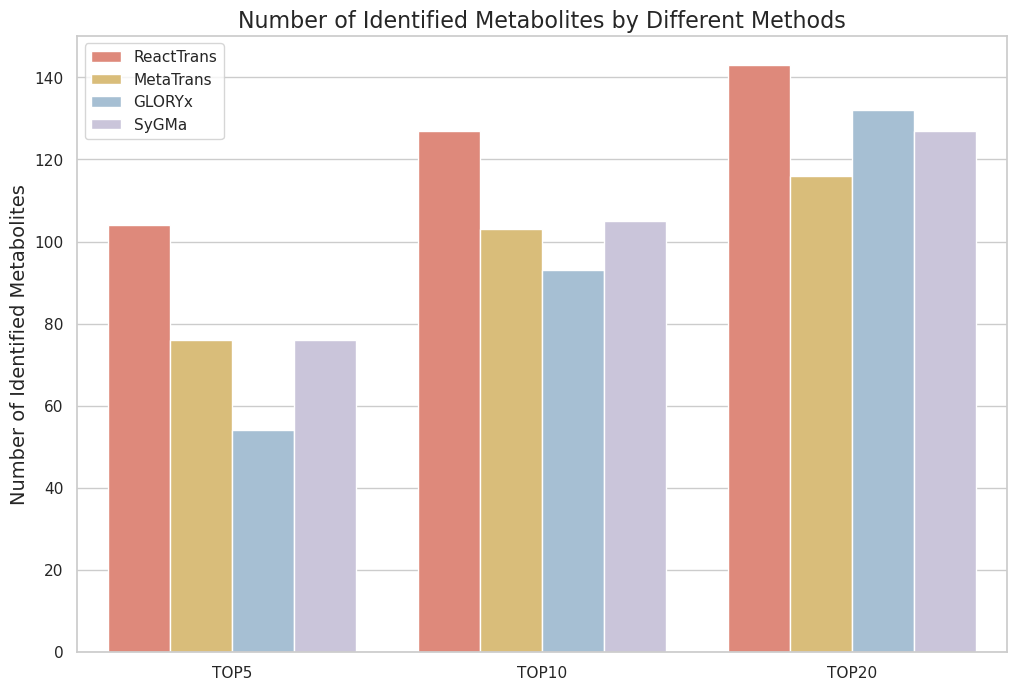

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 示例数据
data = {
    'Method': ['TOP5', 'TOP10', 'TOP20'],
    'ReactTrans': [104, 127, 143],
    'MetaTrans': [76, 103, 116],
    'GLORYx': [54, 93, 132],
    'SyGMa': [76, 105, 127]
}

df = pd.DataFrame(data)

# 将数据从宽格式转换为长格式
df_melted = pd.melt(df, id_vars=['Method'], value_vars=['ReactTrans', 'MetaTrans', 'GLORYx', 'SyGMa'],
                    var_name='Technique', value_name='Predicted_Metabolites')

# 设置Seaborn的样式
sns.set(style="whitegrid")

# 创建一个图形
plt.figure(figsize=(12, 8))

# 使用经典的学术配色方案
palette = sns.color_palette(["#EE7D6B", "#E9C46A", "#9EC0DB", "#C8C1DE"])  # 自定义配色方案

# 绘制多组条形图
ax = sns.barplot(x='Method', y='Predicted_Metabolites', hue='Technique', data=df_melted, palette=palette)

# 添加标题和标签
ax.set_title('Number of Identified Metabolites by Different Methods', fontsize=16)
ax.set_xlabel('')  # 隐藏横轴标签
ax.set_ylabel('Number of Identified Metabolites', fontsize=14)

# 修改图例，去掉"Technique"名字
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='')

# 显示图表
plt.show()


In [ ]:
O=CCCl

In [ ]:
df

,substrate,metabolite,predict,predict_top5,predict_top10,predict_top13,predict_top20
0,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)...,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@...,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@...,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@...,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@...,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@...,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=C/C(=N/O)CC[C@@...
1,CC(C)(O)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1cc...,CC(C)(O)c1ccccc1CC[C@@H](SCC1(CC(=O)OC2O[C@H](...,CC(O)(CO)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1c...,CC(O)(CO)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1c...,CC(O)(CO)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1c...,CC(O)(CO)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1c...,CC(O)(CO)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1c...
2,CC(C)CNCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2)cc1,CC(C)CNCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2O)cc1|N...,NCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2)cc1|CC(C)(O)...,CC(C)C=O.NCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2)cc1...,CC(C)C=O.NCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2)cc1...,CC(C)C=O.NCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2)cc1...,CC(C)C=O.NCc1ccc(-c2ccccc2S(=O)(=O)N2CCCC2)cc1...
3,CC(CN1c2ccccc2Sc2ccccc21)N(C)C,CC(CN1c2ccccc2S(=O)c2ccccc21)N(C)C|CNC(C)CN1c2...,CNC(C)CN1c2ccccc2Sc2ccccc21|CC(CN1C2=C(Sc3cccc...,CNC(C)CN1c2ccccc2Sc2ccccc21|CC(CN1C2=C(Sc3cccc...,CNC(C)CN1c2ccccc2Sc2ccccc21|CC(CN1C2=C(Sc3cccc...,CNC(C)CN1c2ccccc2Sc2ccccc21|CC(CN1C2=C(Sc3cccc...,CNC(C)CN1c2ccccc2Sc2ccccc21|CC(CN1C2=C(Sc3cccc...
4,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...,O=C(NS(=O)(=O)c1ccc(NCC2CCOCC2)c([N+](=O)[O-])...,CC1(C)CCC(C=O)=C(c2ccc(Cl)cc2)C1.O=C(NS(=O)(=O...,CC1(C)CCC(C=O)=C(c2ccc(Cl)cc2)C1.O=C(NS(=O)(=O...,CC1(C)CCC(C=O)=C(c2ccc(Cl)cc2)C1.O=C(NS(=O)(=O...,CC1(C)CCC(C=O)=C(c2ccc(Cl)cc2)C1.O=C(NS(=O)(=O...
...,...,...,...,...,...,...,...
60,O=C(O)c1cc(O)c2c(c1)C(C1c3cc(C(=O)O)cc(O)c3C(=...,O=C(O)c1cc(O)c2c(c1)C(C1c3cccc(O)c3C(=O)c3c(O)...,O=C(O)c1cc(O)c2c(c1)C(C1c3cc(C(=O)O)cc(O)c3C(=...,O=C(O)c1cc(O)c2c(c1)C(C1c3cc(C(=O)O)cc(O)c3C(=...,O=C(O)c1cc(O)c2c(c1)C(C1c3cc(C(=O)O)cc(O)c3C(=...,O=C(O)c1cc(O)c2c(c1)C(C1c3cc(C(=O)O)cc(O)c3C(=...,O=C(O)c1cc(O)c2c(c1)C(C1c3cc(C(=O)O)cc(O)c3C(=...
61,O=C1CN=C(c2ccccc2)c2cc(Cl)ccc2N1,O=C(O)[C@H]1OC(OC2CN=C(c3ccccc3)c3cc(Cl)ccc3N2...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O|NCC(=O)Nc1cc...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O|NCC(=O)Nc1cc...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O|NCC(=O)Nc1cc...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O|NCC(=O)Nc1cc...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O|NCC(=O)Nc1cc...
62,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O,O=C(O)[C@H]1O[C@@H](OC2N=C(c3ccccc3)c3cc(Cl)cc...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1OC1O[C@H](C(=O...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1OC1O[C@H](C(=O...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1OC1O[C@H](C(=O...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1OC1O[C@H](C(=O...,O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1OC1O[C@H](C(=O...
63,O=P1(NCCCl)OCCCN1CCCl,O=CCCl|NP1(=O)OCCCN1CCCl|O=P1(NCCCl)OCCC(O)N1C...,O=P1(NCCCl)OCCC(O)N1CCCl|NP1(=O)OCCCN1CCCl|O=P...,O=P1(NCCCl)OCCC(O)N1CCCl|NP1(=O)OCCCN1CCCl.O=C...,O=P1(NCCCl)OCCC(O)N1CCCl|NP1(=O)OCCCN1CCCl.O=C...,O=P1(NCCCl)OCCC(O)N1CCCl|NP1(=O)OCCCN1CCCl.O=C...,O=P1(NCCCl)OCCC(O)N1CCCl|NP1(=O)OCCCN1CCCl.O=C...


In [ ]:
df.to_csv("predict_all_small_new_add_new11.csv",index=False)

In [ ]:
df.iloc[56]

substrate                   N[C@@H](Cc1cc(O)c(O)cc1[18F])C(=O)O
metabolite                               NCCc1cc(O)c(O)cc1[18F]
predict       N[C@@H](CC1=CC(=O)C(=O)C=C1[18F])C(=O)O|CC(=O)...
Name: 56, dtype: object

In [ ]:
df.iloc[62]

substrate                     O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1O
metabolite    O=C(O)[C@H]1O[C@@H](OC2N=C(c3ccccc3)c3cc(Cl)cc...
predict       O=C1Nc2ccc(Cl)cc2C(c2ccccc2)=NC1OC1O[C@H](C(=O...
Name: 62, dtype: object

In [ ]:
# calculate the accuracy of predicted smiles
#     for pred in original_preds:
#         expanded_preds.extend(pred.split('.'))
# print("Top-K Pred_Set Prediction: ")
k_lis = []
for i in range(num):
    rank = 21
    for k in range(20):
        
        if get_similarity(pre_smiles_50_lis[i][k],truth[i])==1:
            rank = k+1
            break
    k_lis.append(rank)


top20 = 0
top5 = 0
top10 = 0
for i in k_lis:
    if i <= 5:
        top5 += 1
    if i <= 10:
        top10 += 1
    if i <= 20:
        top20 += 1



print(f'Top-5 Pred accuracy after TTA: {top5/num:.4f}')
print(f'Top-10 Pred accuracy after TTA: {top10/num:.4f}')
print(f'Top-20 Pred accuracy after TTA: {top20/num:.4f}')

Top-5 Pred accuracy after TTA: 0.2615
Top-10 Pred accuracy after TTA: 0.2923
Top-20 Pred accuracy after TTA: 0.3385


In [ ]:
# calculate the accuracy of predicted smiles
#     for pred in original_preds:
#         expanded_preds.extend(pred.split('.'))
# print("Top-K Pred_Set Prediction: ")
k_lis = []
for i in range(num):
    rank = 21
    for k in range(20):
        
        if get_similarity(pre_smiles_50_lis[i][k],truth[i])==1:
            rank = k+1
            break
    k_lis.append(rank)


top20 = 0
top5 = 0
top10 = 0
for i in k_lis:
    if i <= 5:
        top5 += 1
    if i <= 10:
        top10 += 1
    if i <= 20:
        top20 += 1



print(f'Top-5 Pred accuracy after TTA: {top5/num:.4f}')
print(f'Top-10 Pred accuracy after TTA: {top10/num:.4f}')
print(f'Top-20 Pred accuracy after TTA: {top20/num:.4f}')

Top-5 Pred accuracy after TTA: 0.2615
Top-10 Pred accuracy after TTA: 0.2923
Top-20 Pred accuracy after TTA: 0.3385


In [ ]:
raw=pd.read_csv("/home/wangyitian/opennmt-model/output/test_set/esmiles/results/neibu/Raw_smiles_1times/predicted/output_step_1000000",sep='\t')

### Calculate top-k accuracy for each reaction type

In [ ]:
class_lis = []
with open('datasets/50k_ReactSeq/aug20_test/2023_7_13_50k_test_r20_v.txt') as f:
    for line in f.readlines():
        class_lis.append(line.split(',')[1])
class_lis = class_lis[:5000]

In [ ]:
for c in range(1,11):
    c ='class_' + str(c)
    num = 0
    top1 = 0
    top3 = 0
    top5 = 0
    top10 = 0
    for i, class_ in zip(k_lis,class_lis):
        if class_ == c:
            num += 1
            if i <= 1:
                top1 += 1
            if i <= 3:
                top3 += 1
            if i <= 5:
                top5 += 1
            if i <= 10:
                top10 += 1
        else:
            pass
    print(c,num)
    print(round(top1/num,4))
    print(round(top3/num,4))
    print(round(top5/num,4))
    print(round(top10/num,4))
    print('')

class_1 12
0.0833
0.1667
0.1667
0.25

class_2 7
0.1429
0.1429
0.1429
0.2857

class_3 18
0.3333
0.3889
0.3889
0.3889

class_4 1
0.0
0.0
0.0
0.0

class_5 6
0.1667
0.1667
0.1667
0.1667

class_6 0


ZeroDivisionError: division by zero

### Calculate top-k accuracy for each edit time

In [ ]:
edit_times_lis = []
for i in range(5000):
    core_edits,chai_edits,stereo_edits,charge_edits,core_edits_add,lg_map_lis = get_edit_from_e_smiles(true_reactseq_lis[i])
    edit_times = len(core_edits) + len(chai_edits) + len(stereo_edits) + len(charge_edits) + len(core_edits_add) + len(lg_map_lis)
    edit_times_lis.append(edit_times)

NameError: name 'true_reactseq_lis' is not defined

In [ ]:
num = 0
top1 = 0
top3 = 0
top5 = 0
top10 = 0
e = 1
for i, edit_time in zip(k_lis,edit_times_lis):
    if edit_time == e:
        num += 1
        if i <= 1:
            top1 += 1
        if i <= 3:
            top3 += 1
        if i <= 5:
            top5 += 1
        if i <= 10:
            top10 += 1
    else:
        pass
print(e,num,num/5000)
print(round(top1/num,4))
print(round(top3/num,4))
print(round(top5/num,4))
print(round(top10/num,4))
print('')


1 194 0.0388
0.5361
0.7938
0.8866
0.9639



In [ ]:
num = 0
top1 = 0
top3 = 0
top5 = 0
top10 = 0
e = 2
for i, edit_time in zip(k_lis,edit_times_lis):
    if edit_time == e:
        num += 1
        if i <= 1:
            top1 += 1
        if i <= 3:
            top3 += 1
        if i <= 5:
            top5 += 1
        if i <= 10:
            top10 += 1
    else:
        pass
print(e,num,num/5000)
print(round(top1/num,4))
print(round(top3/num,4))
print(round(top5/num,4))
print(round(top10/num,4))
print('')


2 3844 0.7688
0.6155
0.8356
0.891
0.9334



In [ ]:
num = 0
top1 = 0
top3 = 0
top5 = 0
top10 = 0
e = 3
for i, edit_time in zip(k_lis,edit_times_lis):
    if edit_time == e:
        num += 1
        if i <= 1:
            top1 += 1
        if i <= 3:
            top3 += 1
        if i <= 5:
            top5 += 1
        if i <= 10:
            top10 += 1
    else:
        pass
print(e,num,num/5000)
print(round(top1/num,4))
print(round(top3/num,4))
print(round(top5/num,4))
print(round(top10/num,4))
print('')


3 648 0.1296
0.3997
0.6265
0.7083
0.8086



In [ ]:
num = 0
top1 = 0
top3 = 0
top5 = 0
top10 = 0
e = 4
for i, edit_time in zip(k_lis,edit_times_lis):
    if edit_time == e:
        num += 1
        if i <= 1:
            top1 += 1
        if i <= 3:
            top3 += 1
        if i <= 5:
            top5 += 1
        if i <= 10:
            top10 += 1
    else:
        pass
print(e,num,num/5000)
print(round(top1/num,4))
print(round(top3/num,4))
print(round(top5/num,4))
print(round(top10/num,4))
print('')


4 238 0.0476
0.7353
0.8319
0.8655
0.8908



In [ ]:
num = 0
top1 = 0
top3 = 0
top5 = 0
top10 = 0
e = 5
for i, edit_time in zip(k_lis,edit_times_lis):
    if edit_time == e:
        num += 1
        if i <= 1:
            top1 += 1
        if i <= 3:
            top3 += 1
        if i <= 5:
            top5 += 1
        if i <= 10:
            top10 += 1
    else:
        pass
print(e,num,num/5000)
print(round(top1/num,4))
print(round(top3/num,4))
print(round(top5/num,4))
print(round(top10/num,4))
print('')


5 28 0.0056
0.5
0.6071
0.6429
0.7143



In [ ]:
num = 0
top1 = 0
top3 = 0
top5 = 0
top10 = 0
e = 6
for i, edit_time in zip(k_lis,edit_times_lis):
    if edit_time >= e:
        num += 1
        if i <= 1:
            top1 += 1
        if i <= 3:
            top3 += 1
        if i <= 5:
            top5 += 1
        if i <= 10:
            top10 += 1
    else:
        pass
print(e,num,num/5000)
print(round(top1/num,4))
print(round(top3/num,4))
print(round(top5/num,4))
print(round(top10/num,4))
print('')


6 48 0.0096
0.5208
0.75
0.7917
0.8333



### Calculate top-k accuracy for Reaction Center Identification

In [ ]:
num = 5000

In [ ]:
ture_reactseq_lis = []
with open('datasets/50k_ReactSeq/aug20_test/2023_7_13_50k_test_r20_v.txt') as f:
    for line in f.readlines():
        ture_reactseq_lis.append(','.join(line.split(',')[2:]).replace('\n',''))

In [ ]:
true_reactseq_lis_g = [[ture_reactseq_lis[i + j*num] for j in range(20)] for i in range(num)]

In [ ]:
len(true_reactseq_lis_g)

5000

In [ ]:
pre_reactseq_50_lis =[[j.split('<')[0] for j in i] for i in pre_reactseq_50_lis]

In [ ]:
pre_reactseq_50_lis_1 = []
for reactseq_50 in pre_reactseq_50_lis_:
    reactseq_50_1 = []
    for reactseq in reactseq_50:
        if reactseq not in reactseq_50_1:
            reactseq_50_1.append(reactseq)
    if len(reactseq_50_1) < 10:
        reactseq_50_1 += ['']*(10 - len(reactseq_50_1))
    pre_reactseq_50_lis_1.append(reactseq_50_1)

In [ ]:
k_lis = []
for i in range(num):
    rank = 11
    for k in range(n):
        if pre_reactseq_50_lis_1[i][k] in [i.split('<')[0] for i in true_reactseq_lis_g[i]]:
            rank = k+1
            break
    k_lis.append(rank)
    
#k_lis

In [ ]:
top1 = 0
top2 = 0
top3 = 0
top5 = 0
top10 = 0
for i in k_lis:
    if i <= 1:
        top1 += 1
    if i <= 2:
        top2 += 1
    if i <= 3:
        top3 += 1
    if i <= 5:
        top5 += 1
    if i <= 10:
        top10 += 1
        

print(f'Top-1 Pred Reaction Center Identification accuracy after TTA: {top1/num:.3f}')
print(f'Top-2 Pred Reaction Center Identification accuracy after TTA: {top2/num:.3f}')
print(f'Top-3 Pred Reaction Center Identification accuracy after TTA: {top3/num:.3f}')
print(f'Top-5 Pred Reaction Center Identification accuracy after TTA: {top5/num:.3f}')
print(f'Top-10 Pred Reaction Center Identification accuracy after TTA: {top10/num:.3f}')

Top-1 Pred Reaction Center Identification accuracy after TTA: 0.731
Top-2 Pred Reaction Center Identification accuracy after TTA: 0.873
Top-3 Pred Reaction Center Identification accuracy after TTA: 0.920
Top-5 Pred Reaction Center Identification accuracy after TTA: 0.955
Top-10 Pred Reaction Center Identification accuracy after TTA: 0.975
